# Random phase approximation many-body response functions

`h.get_spinchi_ladder`/`h.get_spinchi_full` (spin channel) and `h.get_densitychi_RPA` (density/charge
channel) dress the bare susceptibility of a mean-field Hamiltonian with the random phase
approximation, $\chi_{RPA}=\chi(1-U\chi)^{-1}$, using the interaction matrix stored on `h.V` after
convergence. This is not restricted to a single onsite $U$: `h.V`/the `V=` argument can be a real-space
hopping-like dictionary $\{(n_1,n_2,n_3)\!:\!\text{matrix}\}$, so a neighbor-shell exchange ($J_1$)
or density-density interaction ($V_1$) is Fourier-transformed to $V(q)$ and dressed exactly like an
extended hopping. Below, RPA strongly enhances the spin response of an antiferromagnetic chain
relative to the bare (non-interacting) response.

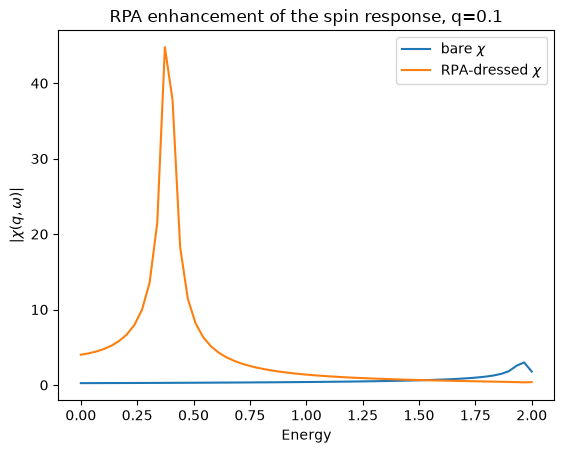

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
g = geometry.bichain() # two sites per cell, so Neel order fits in the cell
h = g.get_hamiltonian(has_spin=True)
seed = h.copy() ; seed.add_antiferromagnetism(0.5) # symmetry-breaking seed
hmf = h.get_mean_field_hamiltonian(U=3.0,filling=0.5,mf=seed,nk=100) # antiferromagnetic state

energies = np.linspace(0.,2.,60)
(es,chi_rpa) = hmf.get_spinchi_ladder(energies=energies,q=[0.1,0.,0.],nk=20,delta=2e-2,RPA=True)
(es,chi_bare) = hmf.get_spinchi_ladder(energies=energies,q=[0.1,0.,0.],nk=20,delta=2e-2,RPA=False)
chi_rpa = np.array(chi_rpa)[:,0,0] # component on the first site of the cell
chi_bare = np.array(chi_bare)[:,0,0]

plt.plot(es,np.abs(chi_bare),label=r"bare $\chi$")
plt.plot(es,np.abs(chi_rpa),label=r"RPA-dressed $\chi$")
plt.xlabel("Energy") ; plt.ylabel(r"$|\chi(q,\omega)|$")
plt.legend()
plt.title("RPA enhancement of the spin response, q=0.1")
plt.show()

Scanning the momentum transfer across the Brillouin zone turns this into a map of the spin
excitations, which is what inelastic neutron scattering measures: the bare response only has the
continuum of particle-hole excitations across the antiferromagnetic gap, while the RPA-dressed one
has in addition a sharp magnon branch below it, which goes to zero energy at $q=0$, the Goldstone
mode of the antiferromagnet.

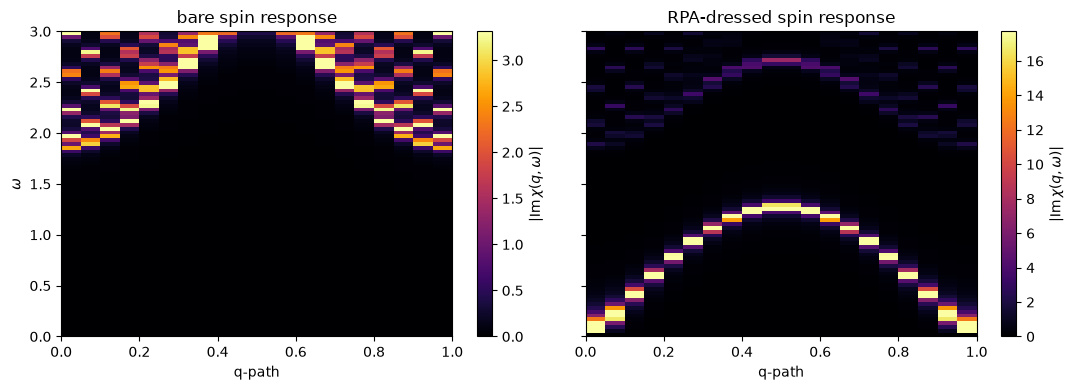

In [2]:
energies = np.linspace(0.,3.,80)
fig,axs = plt.subplots(1,2,figsize=(11,4),sharey=True)
for ax,rpa,title in zip(axs,[False,True],["bare","RPA-dressed"]):
    (qs,es,chis) = hmf.get_qdos_iets(energies=energies,nq=20,nk=20,delta=2e-2,RPA=rpa) # Im Tr chi(q,w)
    chimap = np.abs(np.array(chis)).reshape((-1,len(energies))).T # one column per q-point
    im = ax.imshow(chimap,origin="lower",aspect="auto",cmap="inferno",
                   vmax=np.percentile(chimap,98),extent=[0.,1.,energies[0],energies[-1]])
    plt.colorbar(im,ax=ax,label=r"$|\mathrm{Im}\,\chi(q,\omega)|$")
    ax.set_xlabel("q-path") ; ax.set_title(f"{title} spin response")
axs[0].set_ylabel(r"$\omega$")
plt.tight_layout()
plt.show()